### Geographic Distance Notebook for Development Testing

In [25]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from ecd_helperFunctions import *

def mantel_test(matrix1, matrix2, permutations=1000):
    """
    Perform a Mantel test to calculate the correlation between two distance matrices.
    
    Parameters:
        matrix1: numpy array, first distance matrix
        matrix2: numpy array, second distance matrix
        permutations: int, number of permutations for significance testing
    
    Returns:
        mantel_r: Mantel correlation coefficient
        p_value: p-value for the test
    """
    # Flatten the upper triangle of both matrices to get pairwise distances
    dist1 = matrix1[np.triu_indices_from(matrix1, k=1)]
    dist2 = matrix2[np.triu_indices_from(matrix2, k=1)]
    
    # Calculate the Pearson correlation as the Mantel statistic
    mantel_r, _ = pearsonr(dist1, dist2)
    
    # Permutation test for significance
    permuted_rs = []
    for _ in range(permutations):
        permuted = np.random.permutation(dist2)
        permuted_r, _ = pearsonr(dist1, permuted)
        permuted_rs.append(permuted_r)
    
    # Calculate p-value based on permutations
    permuted_rs = np.array(permuted_rs)
    p_value = np.sum(np.abs(permuted_rs) >= np.abs(mantel_r)) / permutations
    
    return mantel_r, p_value

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Simulated example

# Step 1: Simulate protein expression data (e.g., 5 regions, 3 proteins)
np.random.seed(42)
protein_expression = np.random.rand(5, 3)  # 5 regions, 3 proteins

# Step 2: Assign random geographic coordinates (e.g., x, y for 5 regions)
geographic_coordinates = np.random.rand(5, 2)  # 5 regions, 2D space (x, y)

# Step 3: Calculate Molecular Distance Matrix (Euclidean distance between rows of protein_expression)
molecular_distances = pdist(protein_expression, metric='euclidean')
print(molecular_distances)
molecular_distance_matrix = squareform(molecular_distances)
print(molecular_distance_matrix)
# Step 4: Calculate Geographic Distance Matrix (Euclidean distance between rows of geographic_coordinates)
geographic_distances = pdist(geographic_coordinates, metric='euclidean')
geographic_distance_matrix = squareform(geographic_distances)

# Display results
print("Protein Expression (Regions x Proteins):\n", protein_expression)
print("\nGeographic Coordinates (Regions x Coordinates):\n", geographic_coordinates)
print("\nMolecular Distance Matrix:\n", molecular_distance_matrix)
print("\nGeographic Distance Matrix:\n", geographic_distance_matrix)

# Perform Mantel test
mantel_r, p_value = mantel_test(molecular_distance_matrix, geographic_distance_matrix, permutations=1000)

print(f"Mantel Correlation (r): {mantel_r}")
print(f"P-value: {p_value}")

[1.00675001 0.35273321 1.01636084 1.02837666 0.99733501 0.83232927
 0.24185582 1.12850367 1.09678572 0.82055806]
[[0.         1.00675001 0.35273321 1.01636084 1.02837666]
 [1.00675001 0.         0.99733501 0.83232927 0.24185582]
 [0.35273321 0.99733501 0.         1.12850367 1.09678572]
 [1.01636084 0.83232927 1.12850367 0.         0.82055806]
 [1.02837666 0.24185582 1.09678572 0.82055806 0.        ]]
Protein Expression (Regions x Proteins):
 [[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497]]

Geographic Coordinates (Regions x Coordinates):
 [[0.18340451 0.30424224]
 [0.52475643 0.43194502]
 [0.29122914 0.61185289]
 [0.13949386 0.29214465]
 [0.36636184 0.45606998]]

Molecular Distance Matrix:
 [[0.         1.00675001 0.35273321 1.01636084 1.02837666]
 [1.00675001 0.         0.99733501 0.83232927 0.24185582]
 [0.35273321 0.99733501 0.         1.12850367 1.0967

In [2]:
# Divide tissue into ROIs
# Calculate GD for each ROI
# Create a new condensed matrix where each ROI is a single GD value
# Calculate max-sens and infidelity on new condensed matrix

# Load in CSV as dataframe
s1_df = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC/S1.csv')


# Create dataframe with only x and y coordinates, do not need intensity values in the distance matrix
s1_xy = s1_df[['x_centroid', 'y_centroid']]

# note: Do not need to create an additional intensity dataframe, because
# the coordinates are needed to create the ROIs

# Divide tissue into ROIs
intensity_s1_rois = create_tile_rois(s1_df, 
                           tile_size=1000, 
                           x_coord='x_centroid', 
                           y_coord='y_centroid')

# Create dataframe with only x and y coordinates
xy_s1_rois = create_tile_rois(s1_xy, 
                           tile_size=1000, 
                           x_coord='x_centroid', 
                           y_coord='y_centroid')


/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/ExtendedCorrelationFunctions_ECD/ecd_helperFunctions.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['X_grid'] = (df[x_coord] // tile_size).astype(int)
/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/ExtendedCorrelationFunctions_ECD/ecd_helperFunctions.py:152: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Y_grid'] = (df[y_coord] // tile_size).astype(int)


In [4]:
print(xy_s1_rois.values())
print(intensity_s1_rois.keys())

dict_values([      x_centroid  y_centroid
150      35996.3      2237.2
231      35997.8      2286.5
257      35985.5      2301.5
262      35995.1      2305.4
272      35999.9      2315.5
...          ...         ...
1486     35891.6      2890.5
1487     35906.3      2890.1
1488     35928.2      2892.9
1489     35840.2      2891.3
1490     35899.9      2897.3

[543 rows x 2 columns],       x_centroid  y_centroid
1510     35567.1      3070.9
1512     35558.4      3071.3
1513     35580.2      3071.5
1514     35544.3      3075.4
1515     35591.2      3072.0
...          ...         ...
7759     35847.3      3997.2
7762     35909.6      3998.2
7764     35868.2      3999.2
7771     35887.1      3999.6
7773     35979.8      3999.9

[2097 rows x 2 columns],       x_centroid  y_centroid
7770     35877.9      4000.8
7774     35860.3      4001.7
7775     35993.6      4002.2
7779     35809.6      4005.8
7780     35896.0      4007.0
...          ...         ...
8323     35954.9      4269.8
8330    

In [11]:
# Calculate GD for each ROI
intensity_matrices = intensity_s1_rois.values()
xy_matrices = xy_s1_rois.values()

for intensity_matrix, xy_matrix in zip(intensity_matrices, xy_matrices):
    intensity_perturb = spatial_perturb_matrix(intensity_s1_rois, perturb_columns=['sox2_mean', 'cd45_mean'])
    xy_perturb = spatial_perturb_matrix(xy_s1_rois, perturb_columns=['x_centroid', 'y_centroid'])
    mantel_test(intensity_perturb, xy_perturb, permutations=1000)

KeyError: 'sox2_mean'

In [49]:
gd, bboxes, mantel_dict = calculate_gd(df=s1_df, 
                            perturb_matrix=True,
                            return_bboxes=True)

print(bboxes)
print(gd)
print(mantel_dict)


/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/ExtendedCorrelationFunctions_ECD/ecd_helperFunctions.py:152: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'X_grid'] = (df[x_coord] // tile_size).astype(int)
/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/ExtendedCorrelationFunctions_ECD/ecd_helperFunctions.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Y_grid'] = (df[y_coord] // tile_size).astype(int)
/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/ExtendedCorrelationFunctions_ECD/ecd_help

Calculating perturbed intensity matrix for ROI:  (35, 2) for  0  of  9  ROIs
-0.03808719057929201
Calculating perturbed intensity matrix for ROI:  (35, 3) for  1  of  9  ROIs
0.02385310132517731
Calculating perturbed intensity matrix for ROI:  (35, 4) for  2  of  9  ROIs
0.0025853420275126692
Calculating perturbed intensity matrix for ROI:  (36, 1) for  3  of  9  ROIs
Calculating perturbed intensity matrix for ROI:  (36, 2) for  4  of  9  ROIs
-0.08346359717444142
Calculating perturbed intensity matrix for ROI:  (36, 3) for  5  of  9  ROIs
0.00827230525627891
Calculating perturbed intensity matrix for ROI:  (36, 4) for  6  of  9  ROIs
0.03199593078688863
Calculating perturbed intensity matrix for ROI:  (37, 2) for  7  of  9  ROIs
0.09408189987749638
Calculating perturbed intensity matrix for ROI:  (37, 3) for  8  of  9  ROIs
0.03500418350444724
{(35, 2): [35502, 36000, 2237, 2897], (35, 3): [35251, 36000, 3070, 4000], (35, 4): [35808, 35997, 4000, 4332], (36, 1): [36483, 36483, 1986, 1

Adjusted mantel_values range: 2.6129955629392114 to 5.893766073371914


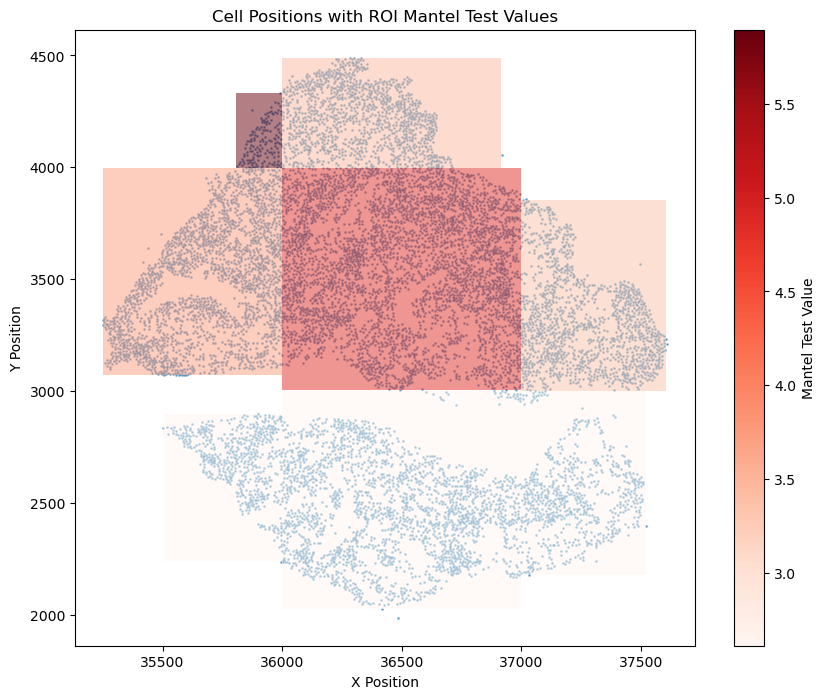

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# Replace NaN values with a default (e.g., the minimum valid value or zero)
mantel_values = [value for value in mantel_dict.values() if not np.isnan(value)]

# Handle edge cases with all NaNs or empty list
if mantel_values:
    vmin, vmax = np.percentile(mantel_values, 5), np.percentile(mantel_values, 95)
    norm = Normalize(vmin=vmin, vmax=vmax)
else:
    vmin, vmax = 0, 1
    norm = Normalize(vmin=vmin, vmax=vmax)

print(f"Adjusted mantel_values range: {vmin} to {vmax}")

# Plotting
plt.figure(figsize=(10, 8))

# Scatter plot
plt.scatter(s1_df['x_centroid'], s1_df['y_centroid'], alpha=0.5, s=1, zorder=1)

# Define colormap
cmap = cm.Reds

# Draw heatmap rectangles
for key in bboxes:
    min_x, max_x, min_y, max_y = bboxes[key]
    width = max_x - min_x
    height = max_y - min_y

    # Get mantel value, replacing NaN with 0
    mantel_value = mantel_dict.get(key, 0)
    mantel_value = mantel_value if not np.isnan(mantel_value) else 0

    # Determine color
    color = cmap(norm(mantel_value))

    # Draw rectangle
    rect = plt.Rectangle((min_x, min_y), width, height, facecolor=color, alpha=0.5, edgecolor='none', zorder=2)
    plt.gca().add_patch(rect)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Cell Positions with ROI Mantel Test Values')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Mantel Test Value')

plt.show()

Adjusted mantel_values range: -0.06758185486613913 to 0.07340469914692915


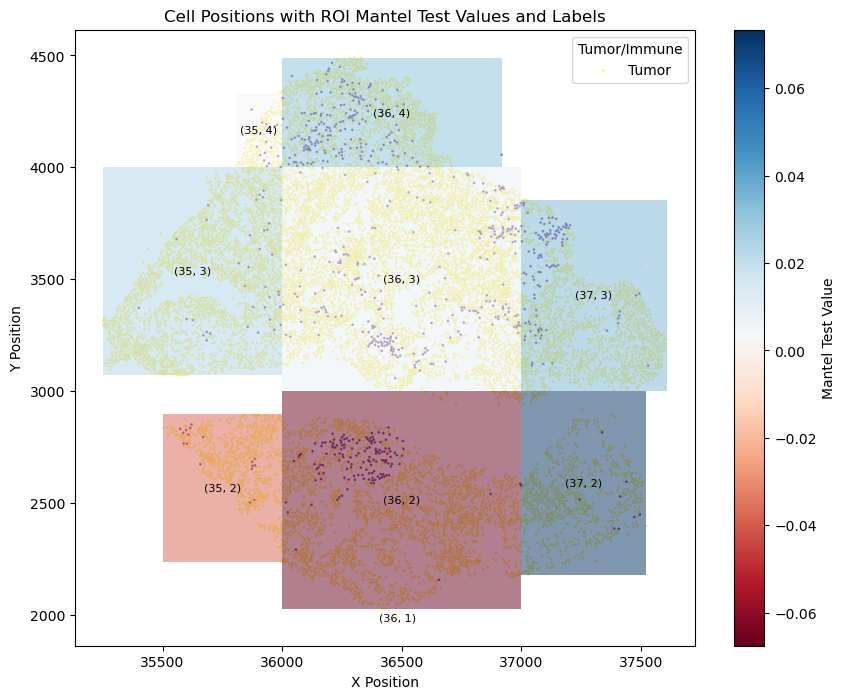

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# Replace NaN values with a default (e.g., the minimum valid value or zero)
mantel_values = [value for value in mantel_dict.values() if not np.isnan(value)]

# Handle edge cases with all NaNs or empty list
if mantel_values:
    vmin, vmax = np.percentile(mantel_values, 5), np.percentile(mantel_values, 95)
    norm = Normalize(vmin=vmin, vmax=vmax)
else:
    vmin, vmax = 0, 1
    norm = Normalize(vmin=vmin, vmax=vmax)

print(f"Adjusted mantel_values range: {vmin} to {vmax}")

# Plotting
plt.figure(figsize=(10, 8))

# Scatter plot with labels
plt.scatter(s1_df['x_centroid'], s1_df['y_centroid'], c=s1_df['tumor_immune'], alpha=0.5, s=1, zorder=1, label='tumor_immune', cmap='viridis')
plt.legend(title='Tumor/Immune', labels=['Tumor', 'Immune'])

# Define colormap
cmap = cm.RdBu

# Draw heatmap rectangles
for key in bboxes:
    min_x, max_x, min_y, max_y = bboxes[key]
    width = max_x - min_x
    height = max_y - min_y

    # Get mantel value, replacing NaN with 0
    mantel_value = mantel_dict.get(key, 0)
    mantel_value = mantel_value if not np.isnan(mantel_value) else 0

    # Determine color
    color = cmap(norm(mantel_value))

    # Draw rectangle
    rect = plt.Rectangle((min_x, min_y), width, height, facecolor=color, alpha=0.5, edgecolor='none', zorder=2)
    plt.gca().add_patch(rect)

    # Calculate the center of the rectangle
    center_x = min_x + width / 2
    center_y = min_y + height / 2

    # Add label at the center
    plt.text(center_x, center_y, f'{key}', color='black', ha='center', va='center', fontsize=8, zorder=3)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Cell Positions with ROI Mantel Test Values and Labels')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Mantel Test Value')

plt.show()